# FASE 6 (RECONSTRUIDA): Clasificacion direccional con SVC en BVG

Objetivo:
- Auditar criticamente el enfoque previo.
- Reconstruir un pipeline de clasificacion temporal sin leakage.
- Comparar SVC (linear/rbf) contra baselines fuertes.

## 1) Auditoria critica previa

Hipotesis de auditoria a validar:
- Regresion de magnitud (retorno t+1) en BVG fue inestable y con baja senal.
- En datos iliquidos, la clasificacion direccional suele ser mas robusta.
- ffill puede suavizar volatilidad y sesgar metricas.
- Superar majority class no basta; hay que superar baseline por signo previo.

In [1]:
# 2) Librerias
import importlib
import subprocess
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if importlib.util.find_spec('sklearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
if importlib.util.find_spec('datasets') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets'])

from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 3) Evidencia minima de literatura que guia decisiones
literature_rows = [
    {
        'paper': 'q5_Quantum_Classical_ML_ABenchmark_Study_for_Financial_Prediction.pdf',
        'decision': 'Usar rolling/walk-forward y out-of-sample estricto'
    },
    {
        'paper': 'sv4_stock_price_prediction_SVR_on_daily_and_minute_prices.pdf',
        'decision': 'Comparar contra baseline competitivo, no solo metrica absoluta'
    },
    {
        'paper': 'qm5_A_survey_on_machine_learning_models_for_financial_time_series_forecasting.pdf',
        'decision': 'Set de features parsimonioso + escalado robusto'
    },
    {
        'paper': 'q2_stock_market_forecasting_basedQFuzzySVM.pdf',
        'decision': 'Considerar robustez a ruido/outliers en clasificacion'
    }
]
literature_df = pd.DataFrame(literature_rows)
display(literature_df)

,paper,decision
0,q5_Quantum_Classical_ML_ABenchmark_Study_for_F...,Usar rolling/walk-forward y out-of-sample estr...
1,sv4_stock_price_prediction_SVR_on_daily_and_mi...,"Comparar contra baseline competitivo, no solo ..."
2,qm5_A_survey_on_machine_learning_models_for_fi...,Set de features parsimonioso + escalado robusto
3,q2_stock_market_forecasting_basedQFuzzySVM.pdf,Considerar robustez a ruido/outliers en clasif...


## 2) Carga de datos y limpieza
Sin forward filling para el pipeline principal.

In [3]:
def canonical_col(name):
    txt = unicodedata.normalize('NFKD', str(name))
    txt = ''.join(ch for ch in txt if ord(ch) < 128)
    return txt.upper().strip()

def find_col(columns, expected):
    cmap = {canonical_col(c): c for c in columns}
    for key in expected:
        if key in cmap:
            return cmap[key]
    for c in columns:
        ccan = canonical_col(c)
        for key in expected:
            if key in ccan:
                return c
    raise KeyError(f'No se encontro columna para {expected}')

def load_raw_df():
    local_path = Path('papers') / 'BVG_Acciones_export.csv'
    if local_path.exists():
        return pd.read_csv(local_path, low_memory=False), 'csv_local'
    ds = load_dataset('beta3/Historical_Data_of_Ecuador_Stock_Exchange', 'default_stocks')
    return ds['stocks'].to_pandas(), 'huggingface_default_stocks'

df_raw, data_source = load_raw_df()
print('Fuente:', data_source)
print('Shape raw:', df_raw.shape)

emisor_col = find_col(df_raw.columns, ['EMISOR'])
fecha_col = find_col(df_raw.columns, ['FECHA NEGOCIACION', 'FECHA'])
precio_col = find_col(df_raw.columns, ['PRECIO', 'CLOSE'])

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
empresas_can = [canonical_col(x) for x in empresas_objetivo]
mapper = dict(zip(empresas_can, empresas_objetivo))

df = df_raw.copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[emisor_col, fecha_col, precio_col]).copy()
df['_emisor_can'] = df[emisor_col].astype(str).map(canonical_col)
df = df[df['_emisor_can'].isin(empresas_can)].copy()
df['empresa'] = df['_emisor_can'].map(mapper)
df = df.sort_values(['empresa', fecha_col]).reset_index(drop=True)

print('Shape filtrado:', df.shape)
display(df[[fecha_col, 'empresa', precio_col]].head())

Fuente: huggingface_default_stocks
Shape raw: (28238, 11)
Shape filtrado: (18006, 13)


,FECHA NEGOCIACIÓN,empresa,PRECIO
0,2019-01-02,BANCO GUAYAQUIL S.A.,0.96
1,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
2,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
3,2019-01-14,BANCO GUAYAQUIL S.A.,0.96
4,2019-01-14,BANCO GUAYAQUIL S.A.,0.95


## 3) Feature engineering y target
Features usadas (justificadas): lag_1, lag_2, roll_mean_3, roll_mean_5, roll_std_3.

In [4]:
feature_cols = ['lag_1', 'lag_2', 'roll_mean_3', 'roll_mean_5', 'roll_std_3']

rows = []
for empresa in empresas_objetivo:
    g = df[df['empresa'] == empresa].copy()
    diario = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
    )

    diario['ret'] = np.log(diario['precio_trade_day'] / diario['precio_trade_day'].shift(1))
    diario['lag_1'] = diario['ret'].shift(1)
    diario['lag_2'] = diario['ret'].shift(2)
    diario['roll_mean_3'] = diario['ret'].rolling(3).mean()
    diario['roll_mean_5'] = diario['ret'].rolling(5).mean()
    diario['roll_std_3'] = diario['ret'].rolling(3).std()

    diario['ret_t1'] = diario['ret'].shift(-1)
    diario['target_cls_t1'] = (diario['ret_t1'] > 0).astype(int)
    diario['baseline_sign_ret_t'] = (diario['ret'] > 0).astype(int)

    diario['empresa'] = empresa
    diario = diario.reset_index().rename(columns={fecha_col: 'fecha'})
    diario = diario.dropna(subset=feature_cols + ['ret', 'ret_t1', 'target_cls_t1']).copy()
    diario = diario.sort_values('fecha').reset_index(drop=True)
    rows.append(diario)

df_model = pd.concat(rows, ignore_index=True)

print('n_samples por empresa:')
print(df_model.groupby('empresa').size().rename('n_samples').to_string())
display(df_model[['fecha', 'empresa', 'ret', 'ret_t1', 'target_cls_t1', 'baseline_sign_ret_t'] + feature_cols].head())

n_samples por empresa:
empresa
BANCO GUAYAQUIL S.A.         1150
CORPORACION FAVORITA C.A.    1685


,fecha,empresa,ret,ret_t1,target_cls_t1,baseline_sign_ret_t,lag_1,lag_2,roll_mean_3,roll_mean_5,roll_std_3
0,2019-01-10,CORPORACION FAVORITA C.A.,0.020285,0.011976,1,1,-0.004090,0.004090,0.006762,0.004057,0.012405
1,2019-01-14,CORPORACION FAVORITA C.A.,0.011976,0.000000,0,1,0.020285,-0.004090,0.009390,0.004820,0.012391
2,2019-01-15,CORPORACION FAVORITA C.A.,0.000000,0.003960,1,0,0.011976,0.020285,0.010754,0.006452,0.010197
3,2019-01-16,CORPORACION FAVORITA C.A.,0.003960,0.027292,1,1,0.000000,0.011976,0.005312,0.006426,0.006101
4,2019-01-17,CORPORACION FAVORITA C.A.,0.027292,-0.007722,0,1,0.003960,0.000000,0.010418,0.012703,0.014747


## 4) Utilidades de evaluacion
Incluye metricas, baselines y utilidades de split temporal.

In [5]:
def directional_accuracy(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

def cls_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'directional_accuracy': directional_accuracy(y_true, y_pred)
    }

def temporal_split(df_emp, train_frac=0.7):
    n = len(df_emp)
    split = int(n * train_frac)
    split = max(100, min(split, n - 50))
    return df_emp.iloc[:split].copy(), df_emp.iloc[split:].copy()

## 5) Holdout temporal (70/30) con tuning en train
Tuning de SVC via TimeSeriesSplit solo sobre train.

In [6]:
param_grid_linear = {'svc__C': [0.1, 1, 10, 50]}
param_grid_rbf = {'svc__C': [0.1, 1, 10, 50], 'svc__gamma': ['scale', 0.01, 0.1, 1]}

holdout_rows = []
holdout_conf = []

for empresa in empresas_objetivo:
    d = df_model[df_model['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)
    train, test = temporal_split(d, train_frac=0.7)

    X_train = train[feature_cols]
    y_train = train['target_cls_t1'].astype(int)
    X_test = test[feature_cols]
    y_test = test['target_cls_t1'].astype(int)

    maj = int(y_train.mode().iloc[0])
    y_pred_maj = np.full(len(y_test), maj, dtype=int)
    y_pred_sign = test['baseline_sign_ret_t'].astype(int).values

    for model_name, y_pred in {
        'baseline_majority': y_pred_maj,
        'baseline_sign_ret_t': y_pred_sign
    }.items():
        m = cls_metrics(y_test, y_pred)
        holdout_rows.append({'empresa': empresa, 'model': model_name, **m})
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        holdout_conf.append({'empresa': empresa, 'model': model_name, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    n_splits = max(3, min(5, len(train) // 80))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    pipe_linear = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='linear'))])
    gs_linear = GridSearchCV(pipe_linear, param_grid_linear, scoring='f1', cv=tscv, n_jobs=-1)
    gs_linear.fit(X_train, y_train)
    y_pred_linear = gs_linear.predict(X_test)
    m_lin = cls_metrics(y_test, y_pred_linear)
    holdout_rows.append({'empresa': empresa, 'model': 'svc_linear', 'best_params': str(gs_linear.best_params_), **m_lin})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_linear, labels=[0, 1]).ravel()
    holdout_conf.append({'empresa': empresa, 'model': 'svc_linear', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    pipe_rbf = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='rbf'))])
    gs_rbf = GridSearchCV(pipe_rbf, param_grid_rbf, scoring='f1', cv=tscv, n_jobs=-1)
    gs_rbf.fit(X_train, y_train)
    y_pred_rbf = gs_rbf.predict(X_test)
    m_rbf = cls_metrics(y_test, y_pred_rbf)
    holdout_rows.append({'empresa': empresa, 'model': 'svc_rbf', 'best_params': str(gs_rbf.best_params_), **m_rbf})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rbf, labels=[0, 1]).ravel()
    holdout_conf.append({'empresa': empresa, 'model': 'svc_rbf', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

holdout_df = pd.DataFrame(holdout_rows)
holdout_conf_df = pd.DataFrame(holdout_conf)
display(holdout_df.sort_values(['empresa', 'f1'], ascending=[True, False]))
display(holdout_conf_df.sort_values(['empresa', 'model']))

,empresa,model,accuracy,precision,recall,f1,directional_accuracy,best_params
7,BANCO GUAYAQUIL S.A.,svc_rbf,0.605797,0.536232,0.262411,0.352381,0.605797,"{'svc__C': 50, 'svc__gamma': 1}"
5,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,0.414493,0.283688,0.283688,0.283688,0.414493,NaN
6,BANCO GUAYAQUIL S.A.,svc_linear,0.594203,1.000000,0.007092,0.014085,0.594203,{'svc__C': 50}
4,BANCO GUAYAQUIL S.A.,baseline_majority,0.591304,0.000000,0.000000,0.000000,0.591304,NaN
3,CORPORACION FAVORITA C.A.,svc_rbf,0.650198,0.392523,0.272727,0.321839,0.650198,"{'svc__C': 50, 'svc__gamma': 1}"
1,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,0.484190,0.154839,0.155844,0.155340,0.484190,NaN
0,CORPORACION FAVORITA C.A.,baseline_majority,0.695652,0.000000,0.000000,0.000000,0.695652,NaN
2,CORPORACION FAVORITA C.A.,svc_linear,0.695652,0.000000,0.000000,0.000000,0.695652,{'svc__C': 0.1}


,empresa,model,tn,fp,fn,tp
4,BANCO GUAYAQUIL S.A.,baseline_majority,204,0,141,0
5,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,103,101,101,40
6,BANCO GUAYAQUIL S.A.,svc_linear,204,0,140,1
7,BANCO GUAYAQUIL S.A.,svc_rbf,172,32,104,37
0,CORPORACION FAVORITA C.A.,baseline_majority,352,0,154,0
1,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,221,131,130,24
2,CORPORACION FAVORITA C.A.,svc_linear,352,0,154,0
3,CORPORACION FAVORITA C.A.,svc_rbf,287,65,112,42


## 6) Walk-forward expanding window (con tuning temporal interno)
Sin random split, sin leakage de escalado.

In [7]:
def tune_svc_on_train(train_df, feature_cols, target_col, model_type='linear', val_frac=0.2, min_val=40):
    n = len(train_df)
    val_size = max(min_val, int(n * val_frac))
    val_size = min(val_size, max(20, n // 3))
    split = n - val_size
    tr = train_df.iloc[:split].copy()
    va = train_df.iloc[split:].copy()

    X_tr = tr[feature_cols].values
    y_tr = tr[target_col].astype(int).values
    X_va = va[feature_cols].values
    y_va = va[target_col].astype(int).values

    if model_type == 'linear':
        grid = [{'C': c} for c in [0.1, 1, 10, 50]]
    else:
        grid = [{'C': c, 'gamma': g} for c in [0.1, 1, 10, 50] for g in ['scale', 0.01, 0.1, 1]]

    best_params, best_f1 = None, -np.inf
    for p in grid:
        scaler = RobustScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_va_s = scaler.transform(X_va)
        if model_type == 'linear':
            model = SVC(kernel='linear', C=p['C'])
        else:
            model = SVC(kernel='rbf', C=p['C'], gamma=p['gamma'])
        model.fit(X_tr_s, y_tr)
        y_va_pred = model.predict(X_va_s)
        score = f1_score(y_va, y_va_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_params = p
    return best_params, best_f1

def fit_predict_svc(train_df, test_df, feature_cols, target_col, model_type, params):
    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].astype(int).values
    X_test = test_df[feature_cols].values
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    if model_type == 'linear':
        model = SVC(kernel='linear', C=params['C'])
    else:
        model = SVC(kernel='rbf', C=params['C'], gamma=params['gamma'])
    model.fit(X_train_s, y_train)
    return model.predict(X_test_s)

def run_walk_forward_cls(data_emp, feature_cols, target_col, initial_train=300, test_size=30, step_size=30):
    d = data_emp.sort_values('fecha').reset_index(drop=True).copy()
    n = len(d)
    if n < (initial_train + test_size + 1):
        initial_train = max(150, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    rows, pred_rows = [], []
    train_end, window_id = initial_train, 0
    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()
        y_test = test[target_col].astype(int).values

        y_train = train[target_col].astype(int).values
        y_pred_maj = np.full(len(test), int(pd.Series(y_train).mode().iloc[0]), dtype=int)
        y_pred_sign = test['baseline_sign_ret_t'].astype(int).values

        for model_name, y_pred in {'baseline_majority': y_pred_maj, 'baseline_sign_ret_t': y_pred_sign}.items():
            m = cls_metrics(y_test, y_pred)
            rows.append({'window_id': window_id, 'model': model_name, 'n_train': len(train), 'n_test': len(test), **m})
            for yt, yp in zip(y_test, y_pred):
                pred_rows.append({'window_id': window_id, 'model': model_name, 'y_true': int(yt), 'y_pred': int(yp)})

        best_lin, best_lin_val = tune_svc_on_train(train, feature_cols, target_col, model_type='linear')
        y_pred_lin = fit_predict_svc(train, test, feature_cols, target_col, 'linear', best_lin)
        m_lin = cls_metrics(y_test, y_pred_lin)
        rows.append({'window_id': window_id, 'model': 'svc_linear', 'best_params': str(best_lin), 'best_val_f1': best_lin_val, 'n_train': len(train), 'n_test': len(test), **m_lin})
        for yt, yp in zip(y_test, y_pred_lin):
            pred_rows.append({'window_id': window_id, 'model': 'svc_linear', 'y_true': int(yt), 'y_pred': int(yp)})

        best_rbf, best_rbf_val = tune_svc_on_train(train, feature_cols, target_col, model_type='rbf')
        y_pred_rbf = fit_predict_svc(train, test, feature_cols, target_col, 'rbf', best_rbf)
        m_rbf = cls_metrics(y_test, y_pred_rbf)
        rows.append({'window_id': window_id, 'model': 'svc_rbf', 'best_params': str(best_rbf), 'best_val_f1': best_rbf_val, 'n_train': len(train), 'n_test': len(test), **m_rbf})
        for yt, yp in zip(y_test, y_pred_rbf):
            pred_rows.append({'window_id': window_id, 'model': 'svc_rbf', 'y_true': int(yt), 'y_pred': int(yp)})

        window_id += 1
        train_end += step_size

    return pd.DataFrame(rows), pd.DataFrame(pred_rows)

wf_rows, wf_pred_rows = [], []
for empresa in empresas_objetivo:
    d_emp = df_model[df_model['empresa'] == empresa].copy()
    res, preds = run_walk_forward_cls(d_emp, feature_cols, 'target_cls_t1', 300, 30, 30)
    if res.empty:
        continue
    res['empresa'] = empresa
    preds['empresa'] = empresa
    wf_rows.append(res)
    wf_pred_rows.append(preds)

wf_df = pd.concat(wf_rows, ignore_index=True)
wf_preds_df = pd.concat(wf_pred_rows, ignore_index=True)
display(wf_df.head())

,window_id,model,n_train,n_test,accuracy,precision,recall,f1,directional_accuracy,best_params,best_val_f1,empresa
0,0,baseline_majority,300,30,0.600000,0.000000,0.000000,0.000000,0.600000,NaN,NaN,CORPORACION FAVORITA C.A.
1,0,baseline_sign_ret_t,300,30,0.366667,0.181818,0.166667,0.173913,0.366667,NaN,NaN,CORPORACION FAVORITA C.A.
2,0,svc_linear,300,30,0.600000,0.000000,0.000000,0.000000,0.600000,{'C': 0.1},0.000000,CORPORACION FAVORITA C.A.
3,0,svc_rbf,300,30,0.566667,0.400000,0.166667,0.235294,0.566667,"{'C': 50, 'gamma': 1}",0.421053,CORPORACION FAVORITA C.A.
4,1,baseline_majority,330,30,0.700000,0.000000,0.000000,0.000000,0.700000,NaN,NaN,CORPORACION FAVORITA C.A.


In [8]:
# 7) Resumen, comparacion vs baseline, estabilidad y confusion matrices
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'directional_accuracy']

wf_summary = (
    wf_df.groupby(['empresa', 'model']).agg(
        n_windows=('window_id', 'count'),
        accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
        precision_mean=('precision', 'mean'), precision_std=('precision', 'std'),
        recall_mean=('recall', 'mean'), recall_std=('recall', 'std'),
        f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
        da_mean=('directional_accuracy', 'mean'), da_std=('directional_accuracy', 'std')
    ).reset_index()
)
display(wf_summary.sort_values(['empresa', 'f1_mean'], ascending=[True, False]))

svc_models = ['svc_linear', 'svc_rbf']
baseline_models = ['baseline_majority', 'baseline_sign_ret_t']
cmp_rows = []
for empresa in empresas_objetivo:
    d = wf_df[wf_df['empresa'] == empresa].copy()
    for svc_m in svc_models:
        d_svc = d[d['model'] == svc_m].sort_values('window_id')
        for base_m in baseline_models:
            d_base = d[d['model'] == base_m].sort_values('window_id')
            merged = d_svc[['window_id'] + metrics_cols].merge(d_base[['window_id'] + metrics_cols], on='window_id', suffixes=('_svc', '_base'))
            if merged.empty:
                continue
            row = {'empresa': empresa, 'svc_model': svc_m, 'baseline_model': base_m, 'n_windows': len(merged)}
            for m in metrics_cols:
                delta = merged[f'{m}_svc'] - merged[f'{m}_base']
                row[f'delta_{m}_mean'] = float(delta.mean())
                row[f'pct_windows_{m}_better'] = float((delta > 0).mean() * 100)
            cmp_rows.append(row)
wf_cmp_df = pd.DataFrame(cmp_rows)
display(wf_cmp_df.sort_values(['empresa', 'svc_model', 'baseline_model']))

cm_rows = []
for empresa in empresas_objetivo:
    for model_name in ['baseline_majority', 'baseline_sign_ret_t', 'svc_linear', 'svc_rbf']:
        sub = wf_preds_df[(wf_preds_df['empresa'] == empresa) & (wf_preds_df['model'] == model_name)]
        if sub.empty:
            continue
        tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1]).ravel()
        cm_rows.append({'empresa': empresa, 'model': model_name, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})
cm_df = pd.DataFrame(cm_rows)
display(cm_df.sort_values(['empresa', 'model']))

,empresa,model,n_windows,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,da_mean,da_std
3,BANCO GUAYAQUIL S.A.,svc_rbf,28,0.659524,0.077171,0.562273,0.320406,0.205704,0.133513,0.278673,0.157926,0.659524,0.077171
1,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,28,0.455952,0.113694,0.209216,0.138575,0.210386,0.140017,0.209594,0.138906,0.455952,0.113694
2,BANCO GUAYAQUIL S.A.,svc_linear,28,0.647619,0.089087,0.035714,0.188982,0.003571,0.018898,0.006494,0.034360,0.647619,0.089087
0,BANCO GUAYAQUIL S.A.,baseline_majority,28,0.646429,0.088582,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.646429,0.088582
7,CORPORACION FAVORITA C.A.,svc_rbf,46,0.650725,0.110160,0.479791,0.273927,0.274925,0.160828,0.317251,0.156823,0.650725,0.110160
5,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,46,0.486232,0.115379,0.184139,0.136727,0.183989,0.137638,0.183871,0.136920,0.486232,0.115379
6,CORPORACION FAVORITA C.A.,svc_linear,46,0.675362,0.094395,0.032609,0.163373,0.008498,0.045933,0.011775,0.060005,0.675362,0.094395
4,CORPORACION FAVORITA C.A.,baseline_majority,46,0.674638,0.094591,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.674638,0.094591


,empresa,svc_model,baseline_model,n_windows,delta_accuracy_mean,pct_windows_accuracy_better,delta_precision_mean,pct_windows_precision_better,delta_recall_mean,pct_windows_recall_better,delta_f1_mean,pct_windows_f1_better,delta_directional_accuracy_mean,pct_windows_directional_accuracy_better
4,BANCO GUAYAQUIL S.A.,svc_linear,baseline_majority,28,0.001190,3.571429,0.035714,3.571429,0.003571,3.571429,0.006494,3.571429,0.001190,3.571429
5,BANCO GUAYAQUIL S.A.,svc_linear,baseline_sign_ret_t,28,0.191667,96.428571,-0.173501,3.571429,-0.206814,0.000000,-0.203101,0.000000,0.191667,96.428571
6,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_majority,28,0.013095,57.142857,0.562273,89.285714,0.205704,89.285714,0.278673,89.285714,0.013095,57.142857
7,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_sign_ret_t,28,0.203571,92.857143,0.353058,82.142857,-0.004682,35.714286,0.069079,57.142857,0.203571,92.857143
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_majority,46,0.000725,2.173913,0.032609,4.347826,0.008498,4.347826,0.011775,4.347826,0.000725,2.173913
1,CORPORACION FAVORITA C.A.,svc_linear,baseline_sign_ret_t,46,0.189130,100.000000,-0.151530,4.347826,-0.175491,2.173913,-0.172096,2.173913,0.189130,100.000000
2,CORPORACION FAVORITA C.A.,svc_rbf,baseline_majority,46,-0.023913,39.130435,0.479791,91.304348,0.274925,91.304348,0.317251,91.304348,-0.023913,39.130435
3,CORPORACION FAVORITA C.A.,svc_rbf,baseline_sign_ret_t,46,0.164493,89.130435,0.295652,82.608696,0.090936,50.000000,0.133380,78.260870,0.164493,89.130435


,empresa,model,tn,fp,fn,tp
4,BANCO GUAYAQUIL S.A.,baseline_majority,543,0,297,0
5,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,315,228,229,68
6,BANCO GUAYAQUIL S.A.,svc_linear,543,0,296,1
7,BANCO GUAYAQUIL S.A.,svc_rbf,489,54,232,65
0,CORPORACION FAVORITA C.A.,baseline_majority,931,0,449,0
1,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,577,354,355,94
2,CORPORACION FAVORITA C.A.,svc_linear,928,3,445,4
3,CORPORACION FAVORITA C.A.,svc_rbf,772,159,323,126


In [9]:
# 8) Analisis final automatico (solo numerico)
print('=== ANALISIS CRITICO AUTOMATICO ===')
final_rows = []
for empresa in empresas_objetivo:
    s = wf_summary[wf_summary['empresa'] == empresa].copy()
    s_svc = s[s['model'].isin(['svc_linear', 'svc_rbf'])].copy()
    s_base = s[s['model'].isin(['baseline_majority', 'baseline_sign_ret_t'])].copy()
    best_svc = s_svc.sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]
    best_base = s_base.sort_values(['f1_mean', 'accuracy_mean'], ascending=False).iloc[0]

    comp = wf_cmp_df[(wf_cmp_df['empresa'] == empresa) & (wf_cmp_df['svc_model'] == best_svc['model']) & (wf_cmp_df['baseline_model'] == best_base['model'])]
    pct_acc_better = float(comp['pct_windows_accuracy_better'].iloc[0]) if not comp.empty else np.nan
    pct_f1_better = float(comp['pct_windows_f1_better'].iloc[0]) if not comp.empty else np.nan

    delta_acc = float(best_svc['accuracy_mean'] - best_base['accuracy_mean'])
    delta_f1 = float(best_svc['f1_mean'] - best_base['f1_mean'])
    supera_consistente = (pct_acc_better >= 60.0) and (pct_f1_better >= 60.0)
    estable = (best_svc['accuracy_std'] <= 0.10) and (best_svc['f1_std'] <= 0.10)
    hay_senal = (delta_acc > 0.0) and (delta_f1 > 0.0) and (best_svc['accuracy_mean'] > 0.50)
    tuning_profundo = supera_consistente and estable and hay_senal

    print('')
    print('Empresa:', empresa)
    print('1) Supera baseline consistentemente?:', 'SI' if supera_consistente else 'NO')
    print('2) Estabilidad del mejor SVC?:', 'ESTABLE' if estable else 'INESTABLE')
    print('3) Evidencia de senal direccional?:', 'SI' if hay_senal else 'NO / DEBIL')
    print('4) Mejor kernel:', best_svc['model'])
    print('5) Se justifica tuning mas profundo?:', 'SI' if tuning_profundo else 'NO')

    final_rows.append({
        'empresa': empresa,
        'best_svc': best_svc['model'],
        'best_baseline': best_base['model'],
        'best_svc_f1_mean': best_svc['f1_mean'],
        'best_baseline_f1_mean': best_base['f1_mean'],
        'delta_f1': delta_f1,
        'best_svc_acc_mean': best_svc['accuracy_mean'],
        'best_baseline_acc_mean': best_base['accuracy_mean'],
        'delta_accuracy': delta_acc,
        'pct_windows_acc_better': pct_acc_better,
        'pct_windows_f1_better': pct_f1_better,
        'stability_flag': 'stable' if estable else 'unstable',
        'signal_flag': 'signal' if hay_senal else 'weak_or_none',
        'tuning_deeper_flag': 'yes' if tuning_profundo else 'no'
    })

final_summary_df = pd.DataFrame(final_rows)
print('\n=== TABLA RESUMEN FINAL ===')
display(final_summary_df)

=== ANALISIS CRITICO AUTOMATICO ===

Empresa: CORPORACION FAVORITA C.A.
1) Supera baseline consistentemente?: SI
2) Estabilidad del mejor SVC?: INESTABLE
3) Evidencia de senal direccional?: SI
4) Mejor kernel: svc_rbf
5) Se justifica tuning mas profundo?: NO

Empresa: BANCO GUAYAQUIL S.A.
1) Supera baseline consistentemente?: NO
2) Estabilidad del mejor SVC?: INESTABLE
3) Evidencia de senal direccional?: SI
4) Mejor kernel: svc_rbf
5) Se justifica tuning mas profundo?: NO

=== TABLA RESUMEN FINAL ===


,empresa,best_svc,best_baseline,best_svc_f1_mean,best_baseline_f1_mean,delta_f1,best_svc_acc_mean,best_baseline_acc_mean,delta_accuracy,pct_windows_acc_better,pct_windows_f1_better,stability_flag,signal_flag,tuning_deeper_flag
0,CORPORACION FAVORITA C.A.,svc_rbf,baseline_sign_ret_t,0.317251,0.183871,0.133380,0.650725,0.486232,0.164493,89.130435,78.260870,unstable,signal,no
1,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_sign_ret_t,0.278673,0.209594,0.069079,0.659524,0.455952,0.203571,92.857143,57.142857,unstable,signal,no


## 9) Recomendaciones si escalas a produccion
- Monitorear drift de clases y de features por emisor.
- Reentrenar con ventana rodante fija.
- Medir desempeno economico con costos de transaccion.
- Definir regla de abstencion cuando la confianza sea baja.

## 10) Extension realista: decision selectiva por confianza

Objetivo de esta extension:
- Pasar de "predecir siempre" a "predecir solo con confianza suficiente".
- Mantener walk-forward temporal sin leakage.
- NO hacer tuning adicional: se usan parametros fijos apoyados en lo aprendido.

Regla de decision (simetrica):
- Si `prob_up >= 0.6` -> predecir SUBE (1)
- Si `prob_up <= 0.4` -> predecir BAJA (0)
- Si `0.4 < prob_up < 0.6` -> NO OPERAR (`NaN`)

In [6]:
# Configuracion de umbrales y modelos fijos (sin tuning en esta fase)
UPPER_TH = 0.60
LOWER_TH = 0.40

fixed_models = {
    # Lineal conservador
    'svc_linear': {'kernel': 'linear', 'C': 1.0, 'probability': True},
    # RBF apoyado en aprendizaje previo de fase 6
    'svc_rbf': {'kernel': 'rbf', 'C': 50, 'gamma': 1, 'probability': True}
}


def decision_from_prob(prob_up, lower=LOWER_TH, upper=UPPER_TH):
    if prob_up >= upper:
        return 1
    if prob_up <= lower:
        return 0
    return np.nan


def filtered_metrics(y_true, y_pred_filtered):
    mask = pd.notna(y_pred_filtered)
    n_total = len(y_true)
    n_oper = int(mask.sum())
    coverage = n_oper / n_total if n_total > 0 else np.nan

    if n_oper == 0:
        return {
            'coverage': coverage,
            'n_oper': n_oper,
            'accuracy_f': np.nan,
            'precision_f': np.nan,
            'recall_f': np.nan,
            'f1_f': np.nan
        }

    yt = np.asarray(y_true)[mask]
    yp = np.asarray(y_pred_filtered)[mask].astype(int)

    return {
        'coverage': coverage,
        'n_oper': n_oper,
        'accuracy_f': accuracy_score(yt, yp),
        'precision_f': precision_score(yt, yp, zero_division=0),
        'recall_f': recall_score(yt, yp, zero_division=0),
        'f1_f': f1_score(yt, yp, zero_division=0)
    }


def run_walk_forward_confidence_eval(data_emp, initial_train=300, test_size=30, step_size=30):
    d = data_emp.sort_values('fecha').reset_index(drop=True).copy()
    n = len(d)

    if n < (initial_train + test_size + 1):
        initial_train = max(150, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    rows = []
    pred_rows = []

    train_end = initial_train
    window_id = 0

    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()

        X_train = train[feature_cols].values
        y_train = train['target_cls_t1'].astype(int).values
        X_test = test[feature_cols].values
        y_test = test['target_cls_t1'].astype(int).values

        # --- Baseline majority con probabilidad constante basada en train ---
        p_up_majority = float(np.mean(y_train))
        prob_up_maj = np.full(len(test), p_up_majority)
        y_pred_hard_maj = (prob_up_maj >= 0.5).astype(int)
        y_pred_fil_maj = np.array([decision_from_prob(p) for p in prob_up_maj], dtype=float)

        m_full_maj = {
            'accuracy_full': accuracy_score(y_test, y_pred_hard_maj),
            'f1_full': f1_score(y_test, y_pred_hard_maj, zero_division=0)
        }
        m_f_maj = filtered_metrics(y_test, y_pred_fil_maj)

        rows.append({
            'window_id': window_id,
            'model': 'baseline_majority',
            'n_train': len(train),
            'n_test': len(test),
            **m_full_maj,
            **m_f_maj
        })

        # --- Baseline signo ret_t con probabilidad condicional en train ---
        train_tmp = train[['ret', 'target_cls_t1']].copy()
        p_up_if_pos = train_tmp.loc[train_tmp['ret'] > 0, 'target_cls_t1'].mean()
        p_up_if_nonpos = train_tmp.loc[train_tmp['ret'] <= 0, 'target_cls_t1'].mean()

        if pd.isna(p_up_if_pos):
            p_up_if_pos = float(np.mean(y_train))
        if pd.isna(p_up_if_nonpos):
            p_up_if_nonpos = float(np.mean(y_train))

        prob_up_sign = np.where(test['ret'].values > 0, p_up_if_pos, p_up_if_nonpos)
        y_pred_hard_sign = (prob_up_sign >= 0.5).astype(int)
        y_pred_fil_sign = np.array([decision_from_prob(p) for p in prob_up_sign], dtype=float)

        m_full_sign = {
            'accuracy_full': accuracy_score(y_test, y_pred_hard_sign),
            'f1_full': f1_score(y_test, y_pred_hard_sign, zero_division=0)
        }
        m_f_sign = filtered_metrics(y_test, y_pred_fil_sign)

        rows.append({
            'window_id': window_id,
            'model': 'baseline_sign_ret_t',
            'n_train': len(train),
            'n_test': len(test),
            **m_full_sign,
            **m_f_sign
        })

        # Guardar predicciones baseline (para analisis/diagnostico)
        for i, (_, r) in enumerate(test.iterrows()):
            pred_rows.append({
                'window_id': window_id,
                'fecha': r['fecha'],
                'empresa': r['empresa'],
                'precio_trade_day': r['precio_trade_day'],
                'y_true': int(y_test[i]),
                'model': 'baseline_majority',
                'prob_up': float(prob_up_maj[i]),
                'confidence': float(max(prob_up_maj[i], 1 - prob_up_maj[i])),
                'y_pred_hard': int(y_pred_hard_maj[i]),
                'y_pred_filtered': y_pred_fil_maj[i]
            })
            pred_rows.append({
                'window_id': window_id,
                'fecha': r['fecha'],
                'empresa': r['empresa'],
                'precio_trade_day': r['precio_trade_day'],
                'y_true': int(y_test[i]),
                'model': 'baseline_sign_ret_t',
                'prob_up': float(prob_up_sign[i]),
                'confidence': float(max(prob_up_sign[i], 1 - prob_up_sign[i])),
                'y_pred_hard': int(y_pred_hard_sign[i]),
                'y_pred_filtered': y_pred_fil_sign[i]
            })

        # --- SVCs con probabilidad ---
        for model_name, params in fixed_models.items():
            scaler = RobustScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)

            clf = SVC(**params)
            clf.fit(X_train_s, y_train)

            y_pred_hard = clf.predict(X_test_s)
            prob_up = clf.predict_proba(X_test_s)[:, 1]
            y_pred_fil = np.array([decision_from_prob(p) for p in prob_up], dtype=float)

            m_full = {
                'accuracy_full': accuracy_score(y_test, y_pred_hard),
                'f1_full': f1_score(y_test, y_pred_hard, zero_division=0)
            }
            m_f = filtered_metrics(y_test, y_pred_fil)

            rows.append({
                'window_id': window_id,
                'model': model_name,
                'n_train': len(train),
                'n_test': len(test),
                **m_full,
                **m_f
            })

            for i, (_, r) in enumerate(test.iterrows()):
                pred_rows.append({
                    'window_id': window_id,
                    'fecha': r['fecha'],
                    'empresa': r['empresa'],
                    'precio_trade_day': r['precio_trade_day'],
                    'y_true': int(y_test[i]),
                    'model': model_name,
                    'prob_up': float(prob_up[i]),
                    'confidence': float(max(prob_up[i], 1 - prob_up[i])),
                    'y_pred_hard': int(y_pred_hard[i]),
                    'y_pred_filtered': y_pred_fil[i]
                })

        window_id += 1
        train_end += step_size

    return pd.DataFrame(rows), pd.DataFrame(pred_rows)


wf_conf_rows = []
wf_conf_preds_rows = []

for empresa in empresas_objetivo:
    d_emp = df_model[df_model['empresa'] == empresa].copy()
    res_conf, pred_conf = run_walk_forward_confidence_eval(d_emp, initial_train=300, test_size=30, step_size=30)

    if res_conf.empty:
        continue

    res_conf['empresa'] = empresa
    pred_conf['empresa'] = empresa

    wf_conf_rows.append(res_conf)
    wf_conf_preds_rows.append(pred_conf)

wf_conf_df = pd.concat(wf_conf_rows, ignore_index=True)
wf_conf_preds_df = pd.concat(wf_conf_preds_rows, ignore_index=True)

print('Shape resultados por ventana (confidence eval):', wf_conf_df.shape)
display(wf_conf_df.head())

Shape resultados por ventana (confidence eval): (296, 13)


,window_id,model,n_train,n_test,accuracy_full,f1_full,coverage,n_oper,accuracy_f,precision_f,recall_f,f1_f,empresa
0,0,baseline_majority,300,30,0.600000,0.000000,1.000000,30,0.600000,0.0,0.0,0.0,CORPORACION FAVORITA C.A.
1,0,baseline_sign_ret_t,300,30,0.600000,0.000000,0.366667,11,0.818182,0.0,0.0,0.0,CORPORACION FAVORITA C.A.
2,0,svc_linear,300,30,0.600000,0.000000,1.000000,30,0.600000,0.0,0.0,0.0,CORPORACION FAVORITA C.A.
3,0,svc_rbf,300,30,0.566667,0.235294,0.900000,27,0.629630,0.0,0.0,0.0,CORPORACION FAVORITA C.A.
4,1,baseline_majority,330,30,0.700000,0.000000,1.000000,30,0.700000,0.0,0.0,0.0,CORPORACION FAVORITA C.A.


In [7]:
# Resumen por empresa/modelo: metricas completas vs metricas filtradas
conf_summary = (
    wf_conf_df
    .groupby(['empresa', 'model'])
    .agg(
        n_windows=('window_id', 'count'),
        accuracy_full_mean=('accuracy_full', 'mean'),
        accuracy_full_std=('accuracy_full', 'std'),
        f1_full_mean=('f1_full', 'mean'),
        f1_full_std=('f1_full', 'std'),
        coverage_mean=('coverage', 'mean'),
        coverage_std=('coverage', 'std'),
        accuracy_f_mean=('accuracy_f', 'mean'),
        accuracy_f_std=('accuracy_f', 'std'),
        precision_f_mean=('precision_f', 'mean'),
        recall_f_mean=('recall_f', 'mean'),
        f1_f_mean=('f1_f', 'mean'),
        f1_f_std=('f1_f', 'std')
    )
    .reset_index()
)

display(conf_summary.sort_values(['empresa', 'f1_f_mean'], ascending=[True, False]))

# Comparacion justa modelo vs baseline bajo el MISMO esquema de abstencion
cmp_conf_rows = []
svc_models = ['svc_linear', 'svc_rbf']
baseline_models = ['baseline_majority', 'baseline_sign_ret_t']

for empresa in empresas_objetivo:
    d = wf_conf_df[wf_conf_df['empresa'] == empresa].copy()
    for svc_m in svc_models:
        d_svc = d[d['model'] == svc_m].sort_values('window_id')
        for base_m in baseline_models:
            d_base = d[d['model'] == base_m].sort_values('window_id')
            m = d_svc[['window_id', 'accuracy_f', 'f1_f', 'coverage']].merge(
                d_base[['window_id', 'accuracy_f', 'f1_f', 'coverage']],
                on='window_id', suffixes=('_svc', '_base')
            )
            if m.empty:
                continue

            delta_acc_f = m['accuracy_f_svc'] - m['accuracy_f_base']
            delta_f1_f = m['f1_f_svc'] - m['f1_f_base']
            delta_cov = m['coverage_svc'] - m['coverage_base']

            cmp_conf_rows.append({
                'empresa': empresa,
                'svc_model': svc_m,
                'baseline_model': base_m,
                'n_windows': len(m),
                'delta_accuracy_f_mean': float(delta_acc_f.mean()),
                'delta_f1_f_mean': float(delta_f1_f.mean()),
                'delta_coverage_mean': float(delta_cov.mean()),
                'pct_windows_acc_f_better': float((delta_acc_f > 0).mean() * 100),
                'pct_windows_f1_f_better': float((delta_f1_f > 0).mean() * 100)
            })

conf_cmp_df = pd.DataFrame(cmp_conf_rows)
display(conf_cmp_df.sort_values(['empresa', 'svc_model', 'baseline_model']))

# Trade-off explicito: mejora vs caida de cobertura respecto al mismo modelo sin filtro
tradeoff_rows = []
for empresa in empresas_objetivo:
    for model_name in ['svc_linear', 'svc_rbf', 'baseline_majority', 'baseline_sign_ret_t']:
        s = conf_summary[(conf_summary['empresa'] == empresa) & (conf_summary['model'] == model_name)]
        if s.empty:
            continue
        r = s.iloc[0]
        tradeoff_rows.append({
            'empresa': empresa,
            'model': model_name,
            'delta_acc_filter_vs_full': float(r['accuracy_f_mean'] - r['accuracy_full_mean']),
            'delta_f1_filter_vs_full': float(r['f1_f_mean'] - r['f1_full_mean']),
            'coverage_mean': float(r['coverage_mean'])
        })

tradeoff_df = pd.DataFrame(tradeoff_rows)
display(tradeoff_df.sort_values(['empresa', 'model']))

,empresa,model,n_windows,accuracy_full_mean,accuracy_full_std,f1_full_mean,f1_full_std,coverage_mean,coverage_std,accuracy_f_mean,accuracy_f_std,precision_f_mean,recall_f_mean,f1_f_mean,f1_f_std
2,BANCO GUAYAQUIL S.A.,svc_linear,28,0.647619,0.089087,0.006494,0.034360,0.971429,0.049453,0.659143,0.092267,0.107143,0.013393,0.023635,0.071762
0,BANCO GUAYAQUIL S.A.,baseline_majority,28,0.646429,0.088582,0.000000,0.000000,1.000000,0.000000,0.646429,0.088582,0.000000,0.000000,0.000000,0.000000
1,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,28,0.646429,0.088582,0.000000,0.000000,1.000000,0.000000,0.646429,0.088582,0.000000,0.000000,0.000000,0.000000
3,BANCO GUAYAQUIL S.A.,svc_rbf,28,0.647619,0.077740,0.307606,0.169865,0.951190,0.061183,0.652253,0.089039,0.000000,0.000000,0.000000,0.000000
6,CORPORACION FAVORITA C.A.,svc_linear,46,0.675362,0.094395,0.015481,0.083570,0.964493,0.078379,0.683915,0.099996,0.021739,0.002717,0.004831,0.032765
4,CORPORACION FAVORITA C.A.,baseline_majority,46,0.674638,0.094591,0.000000,0.000000,1.000000,0.000000,0.674638,0.094591,0.000000,0.000000,0.000000,0.000000
5,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,46,0.674638,0.094591,0.000000,0.000000,0.723913,0.339110,0.720211,0.119391,0.000000,0.000000,0.000000,0.000000
7,CORPORACION FAVORITA C.A.,svc_rbf,46,0.626812,0.114530,0.349479,0.154635,0.885507,0.092069,0.686424,0.091550,0.000000,0.000000,0.000000,0.000000


,empresa,svc_model,baseline_model,n_windows,delta_accuracy_f_mean,delta_f1_f_mean,delta_coverage_mean,pct_windows_acc_f_better,pct_windows_f1_f_better
4,BANCO GUAYAQUIL S.A.,svc_linear,baseline_majority,28,0.012714,0.023635,-0.028571,28.571429,10.714286
5,BANCO GUAYAQUIL S.A.,svc_linear,baseline_sign_ret_t,28,0.012714,0.023635,-0.028571,28.571429,10.714286
6,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_majority,28,0.005825,0.000000,-0.048810,32.142857,0.000000
7,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_sign_ret_t,28,0.005825,0.000000,-0.048810,32.142857,0.000000
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_majority,46,0.009277,0.004831,-0.035507,17.391304,2.173913
1,CORPORACION FAVORITA C.A.,svc_linear,baseline_sign_ret_t,46,-0.036296,0.004831,0.240580,15.217391,2.173913
2,CORPORACION FAVORITA C.A.,svc_rbf,baseline_majority,46,0.011787,0.000000,-0.114493,58.695652,0.000000
3,CORPORACION FAVORITA C.A.,svc_rbf,baseline_sign_ret_t,46,-0.033787,0.000000,0.161594,39.130435,0.000000


,empresa,model,delta_acc_filter_vs_full,delta_f1_filter_vs_full,coverage_mean
6,BANCO GUAYAQUIL S.A.,baseline_majority,0.000000,0.000000,1.000000
7,BANCO GUAYAQUIL S.A.,baseline_sign_ret_t,0.000000,0.000000,1.000000
4,BANCO GUAYAQUIL S.A.,svc_linear,0.011524,0.017142,0.971429
5,BANCO GUAYAQUIL S.A.,svc_rbf,0.004634,-0.307606,0.951190
2,CORPORACION FAVORITA C.A.,baseline_majority,0.000000,0.000000,1.000000
3,CORPORACION FAVORITA C.A.,baseline_sign_ret_t,0.045573,0.000000,0.723913
0,CORPORACION FAVORITA C.A.,svc_linear,0.008552,-0.010650,0.964493
1,CORPORACION FAVORITA C.A.,svc_rbf,0.059613,-0.349479,0.885507


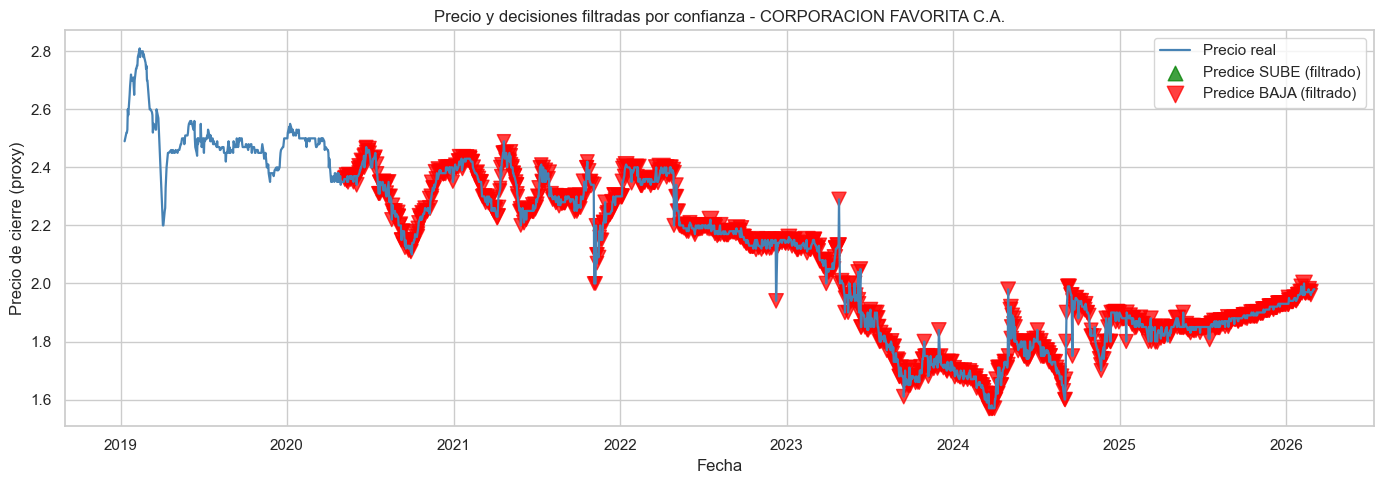

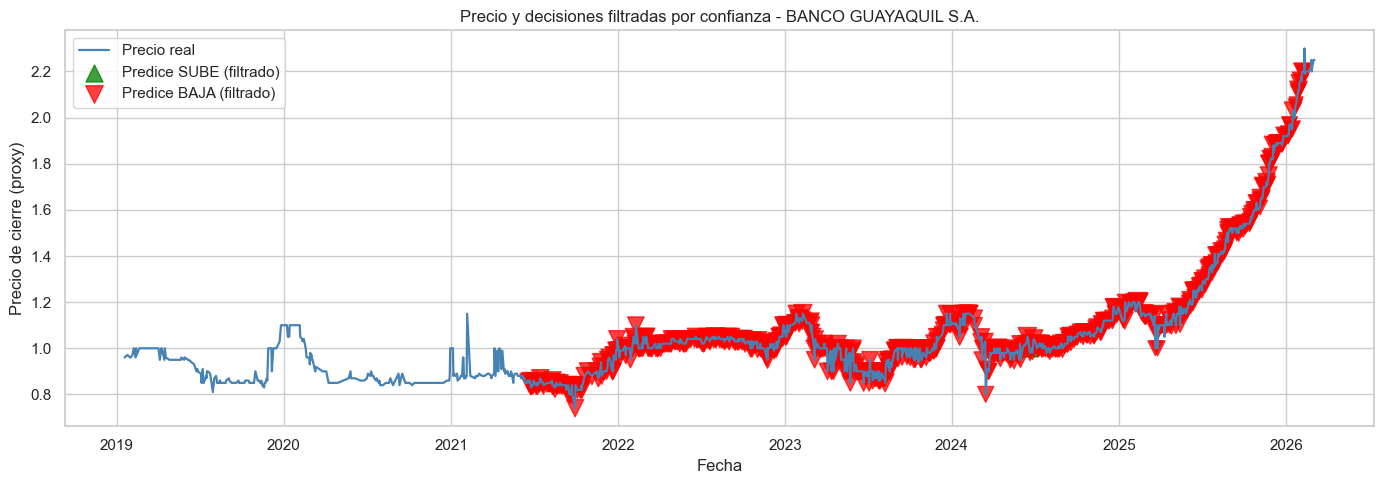

In [8]:
# Visualizacion obligatoria por empresa: precio + senales filtradas
# Se usa SVC-RBF por ser el modelo que mejor rindio en fase previa y en esta extension.
for empresa in empresas_objetivo:
    base_price = (
        df_model[df_model['empresa'] == empresa][['fecha', 'precio_trade_day']]
        .drop_duplicates(subset=['fecha'])
        .sort_values('fecha')
    )

    pred_best = wf_conf_preds_df[
        (wf_conf_preds_df['empresa'] == empresa) &
        (wf_conf_preds_df['model'] == 'svc_rbf')
    ].copy()

    pred_best = pred_best[pd.notna(pred_best['y_pred_filtered'])].copy()

    up = pred_best[pred_best['y_pred_filtered'] == 1].copy()
    down = pred_best[pred_best['y_pred_filtered'] == 0].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(base_price['fecha'], base_price['precio_trade_day'], color='steelblue', linewidth=1.6, label='Precio real')

    if not up.empty:
        size_up = 40 + 220 * (up['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(
            up['fecha'], up['precio_trade_day'],
            s=size_up,
            marker='^',
            color='green',
            alpha=0.75,
            label='Predice SUBE (filtrado)'
        )

    if not down.empty:
        size_down = 40 + 220 * (down['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(
            down['fecha'], down['precio_trade_day'],
            s=size_down,
            marker='v',
            color='red',
            alpha=0.75,
            label='Predice BAJA (filtrado)'
        )

    plt.title(f'Precio y decisiones filtradas por confianza - {empresa}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio de cierre (proxy)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [9]:
# 11) Analisis final obligatorio: valor real bajo decision selectiva
print('=== ANALISIS FINAL: CONFIANZA Y TOMA DE DECISION SELECTIVA ===')

final_conf_rows = []

for empresa in empresas_objetivo:
    s = conf_summary[conf_summary['empresa'] == empresa].copy()
    s_svc = s[s['model'].isin(['svc_linear', 'svc_rbf'])].copy()
    s_base = s[s['model'].isin(['baseline_majority', 'baseline_sign_ret_t'])].copy()

    best_svc = s_svc.sort_values(['f1_f_mean', 'accuracy_f_mean'], ascending=False).iloc[0]
    best_base = s_base.sort_values(['f1_f_mean', 'accuracy_f_mean'], ascending=False).iloc[0]

    cmp = conf_cmp_df[
        (conf_cmp_df['empresa'] == empresa) &
        (conf_cmp_df['svc_model'] == best_svc['model']) &
        (conf_cmp_df['baseline_model'] == best_base['model'])
    ]

    pct_acc_better = float(cmp['pct_windows_acc_f_better'].iloc[0]) if not cmp.empty else np.nan
    pct_f1_better = float(cmp['pct_windows_f1_f_better'].iloc[0]) if not cmp.empty else np.nan

    delta_acc_f = float(best_svc['accuracy_f_mean'] - best_base['accuracy_f_mean'])
    delta_f1_f = float(best_svc['f1_f_mean'] - best_base['f1_f_mean'])

    # Trade-off interno del mejor SVC (filtrado vs no filtrado)
    trow = tradeoff_df[(tradeoff_df['empresa'] == empresa) & (tradeoff_df['model'] == best_svc['model'])].iloc[0]
    delta_acc_vs_full = float(trow['delta_acc_filter_vs_full'])
    delta_f1_vs_full = float(trow['delta_f1_filter_vs_full'])
    coverage = float(trow['coverage_mean'])

    improves_with_filter = (delta_acc_vs_full > 0) and (delta_f1_vs_full > 0)
    severe_coverage_drop = coverage < 0.35

    consistency = (pct_acc_better >= 60.0) and (pct_f1_better >= 60.0)
    stable_enough = (best_svc['accuracy_f_std'] <= 0.10) and (best_svc['f1_f_std'] <= 0.10)

    print('')
    print(f'Empresa: {empresa}')
    print(f'- Mejor SVC filtrado: {best_svc["model"]}')
    print(f'- Mejor baseline filtrado: {best_base["model"]}')
    print(f'- Cobertura media del mejor SVC: {coverage:.3f}')
    print(f'- Delta accuracy (filtrado - full) del mejor SVC: {delta_acc_vs_full:.4f}')
    print(f'- Delta F1 (filtrado - full) del mejor SVC: {delta_f1_vs_full:.4f}')
    print(f'- Delta accuracy filtrado vs baseline filtrado: {delta_acc_f:.4f}')
    print(f'- Delta F1 filtrado vs baseline filtrado: {delta_f1_f:.4f}')
    print(f'- % ventanas mejor que baseline (acc_f / f1_f): {pct_acc_better:.2f}% / {pct_f1_better:.2f}%')
    print(f'- Estabilidad filtrada (std acc/f1): {best_svc["accuracy_f_std"]:.4f} / {best_svc["f1_f_std"]:.4f}')

    print('Conclusiones duras:')
    print(f'1) Mejora al filtrar por confianza?: {"SI" if improves_with_filter else "NO"}')
    print(f'2) La cobertura cae fuertemente?: {"SI" if severe_coverage_drop else "NO"}')
    print(f'3) Trade-off menos predicciones vs mayor calidad?: {"SI" if (improves_with_filter and severe_coverage_drop) else "PARCIAL/NO"}')
    print(f'4) Consistencia contra baseline bajo filtro?: {"SI" if consistency else "NO"}')
    print(f'5) Inestabilidad residual?: {"ALTA" if not stable_enough else "MODERADA"}')

    usable_real_system = consistency and stable_enough and (coverage >= 0.35)
    print(f'6) Usable en sistema real hoy?: {"SI" if usable_real_system else "NO"}')

    final_conf_rows.append({
        'empresa': empresa,
        'best_svc_filtered': best_svc['model'],
        'best_baseline_filtered': best_base['model'],
        'coverage_mean_best_svc': coverage,
        'delta_acc_filter_vs_full': delta_acc_vs_full,
        'delta_f1_filter_vs_full': delta_f1_vs_full,
        'delta_acc_filtered_vs_baseline': delta_acc_f,
        'delta_f1_filtered_vs_baseline': delta_f1_f,
        'pct_windows_acc_f_better': pct_acc_better,
        'pct_windows_f1_f_better': pct_f1_better,
        'filtered_stability_acc_std': float(best_svc['accuracy_f_std']),
        'filtered_stability_f1_std': float(best_svc['f1_f_std']),
        'usable_real_system_flag': 'yes' if usable_real_system else 'no'
    })

final_conf_summary_df = pd.DataFrame(final_conf_rows)
print('\n=== TABLA FINAL CON FILTRO DE CONFIANZA ===')
display(final_conf_summary_df)

=== ANALISIS FINAL: CONFIANZA Y TOMA DE DECISION SELECTIVA ===

Empresa: CORPORACION FAVORITA C.A.
- Mejor SVC filtrado: svc_linear
- Mejor baseline filtrado: baseline_sign_ret_t
- Cobertura media del mejor SVC: 0.964
- Delta accuracy (filtrado - full) del mejor SVC: 0.0086
- Delta F1 (filtrado - full) del mejor SVC: -0.0106
- Delta accuracy filtrado vs baseline filtrado: -0.0363
- Delta F1 filtrado vs baseline filtrado: 0.0048
- % ventanas mejor que baseline (acc_f / f1_f): 15.22% / 2.17%
- Estabilidad filtrada (std acc/f1): 0.1000 / 0.0328
Conclusiones duras:
1) Mejora al filtrar por confianza?: NO
2) La cobertura cae fuertemente?: NO
3) Trade-off menos predicciones vs mayor calidad?: PARCIAL/NO
4) Consistencia contra baseline bajo filtro?: NO
5) Inestabilidad residual?: MODERADA
6) Usable en sistema real hoy?: NO

Empresa: BANCO GUAYAQUIL S.A.
- Mejor SVC filtrado: svc_linear
- Mejor baseline filtrado: baseline_majority
- Cobertura media del mejor SVC: 0.971
- Delta accuracy (filtra

,empresa,best_svc_filtered,best_baseline_filtered,coverage_mean_best_svc,delta_acc_filter_vs_full,delta_f1_filter_vs_full,delta_acc_filtered_vs_baseline,delta_f1_filtered_vs_baseline,pct_windows_acc_f_better,pct_windows_f1_f_better,filtered_stability_acc_std,filtered_stability_f1_std,usable_real_system_flag
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_sign_ret_t,0.964493,0.008552,-0.010650,-0.036296,0.004831,15.217391,2.173913,0.099996,0.032765,no
1,BANCO GUAYAQUIL S.A.,svc_linear,baseline_majority,0.971429,0.011524,0.017142,0.012714,0.023635,28.571429,10.714286,0.092267,0.071762,no
